In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
week2 = pd.read_csv("../data/processed/week2_final_comparison.csv")

dqn = pd.read_csv("../data/processed/policy_evaluation.csv")

print("Week 2 Results")
display(week2.head())

print()

print("Policy Evaluation")
display(dqn.head())

Week 2 Results


,Strategy,Average Revenue,Average Rooms Sold,Average Occupancy (%),Average Price,Episodes
0,Fixed,3638.50,38.30,76.60,120.000000,50
1,Random,3202.10,37.74,75.48,119.493333,50
2,Discount,3051.50,36.58,73.16,126.666667,50
3,Q-Learning,2908.25,46.63,93.26,92.413690,100



Policy Evaluation


,Season,Revenue,Rooms Sold,Occupancy (%),Average Price
0,1,3255,37,74.0,118.666667
1,2,2570,30,60.0,118.666667
2,3,3840,48,96.0,114.000000
3,4,3440,40,80.0,114.666667
4,5,2800,32,64.0,118.666667


In [3]:
dqn_summary = pd.DataFrame({
    "Strategy":["Deep Q-Network"],
    "Average Revenue":[round(dqn["Revenue"].mean(),2)],
    "Average Rooms Sold":[round(dqn["Rooms Sold"].mean(),2)],
    "Average Occupancy (%)":[round(dqn["Occupancy (%)"].mean(),2)],
    "Average Price":[round(dqn["Average Price"].mean(),2)],
    "Episodes":[1000]
})

dqn_summary

,Strategy,Average Revenue,Average Rooms Sold,Average Occupancy (%),Average Price,Episodes
0,Deep Q-Network,3384.61,39.7,79.4,117.84,1000


In [4]:
comparison = pd.concat([week2,dqn_summary],ignore_index=True)

comparison

,Strategy,Average Revenue,Average Rooms Sold,Average Occupancy (%),Average Price,Episodes
0,Fixed,3638.50,38.30,76.60,120.000000,50
1,Random,3202.10,37.74,75.48,119.493333,50
2,Discount,3051.50,36.58,73.16,126.666667,50
3,Q-Learning,2908.25,46.63,93.26,92.413690,100
4,Deep Q-Network,3384.61,39.70,79.40,117.840000,1000


In [5]:
comparison.to_csv("../data/processed/final_strategy_comparison.csv",index=False)

print("Comparison dataset saved successfully.")

Comparison dataset saved successfully.


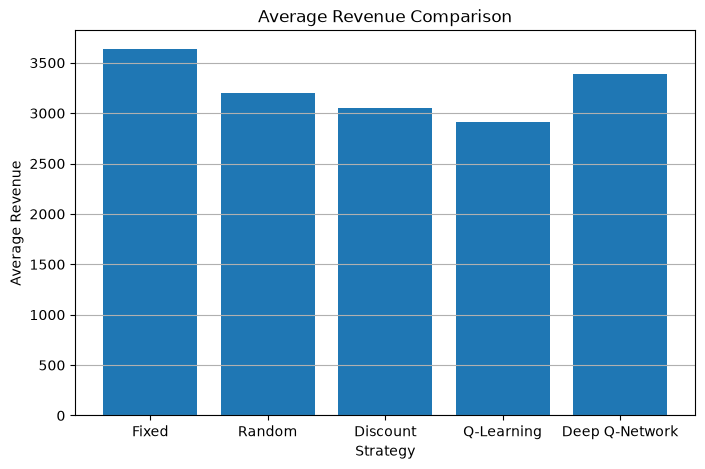

In [6]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Strategy"],comparison["Average Revenue"])

plt.title("Average Revenue Comparison")

plt.xlabel("Strategy")

plt.ylabel("Average Revenue")

plt.grid(axis="y")

plt.show()

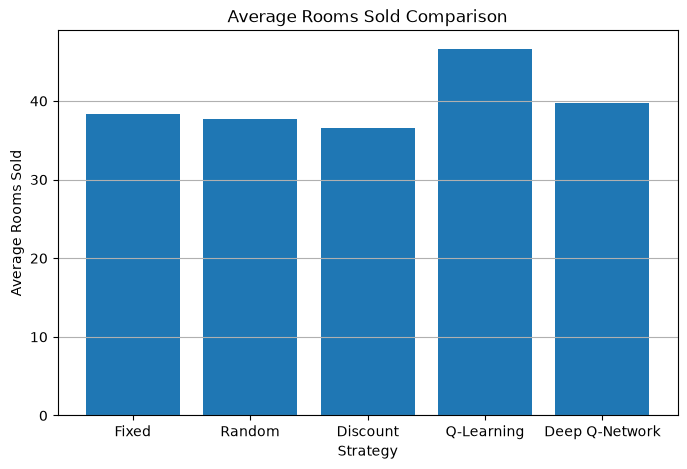

In [7]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Strategy"],comparison["Average Rooms Sold"])

plt.title("Average Rooms Sold Comparison")

plt.xlabel("Strategy")

plt.ylabel("Average Rooms Sold")

plt.grid(axis="y")

plt.show()

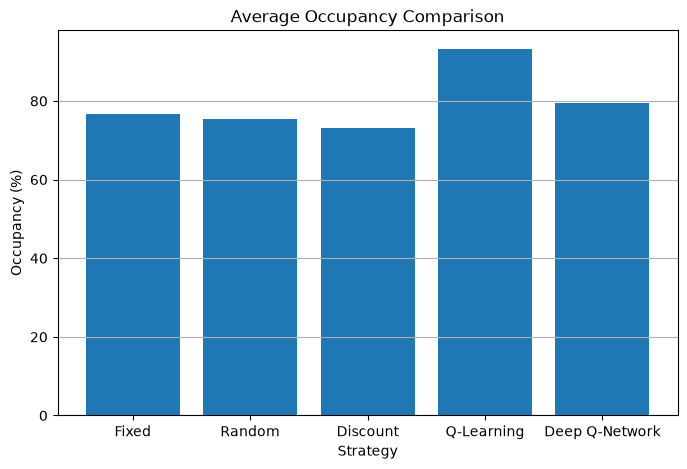

In [8]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Strategy"],comparison["Average Occupancy (%)"])

plt.title("Average Occupancy Comparison")

plt.xlabel("Strategy")

plt.ylabel("Occupancy (%)")

plt.grid(axis="y")

plt.show()

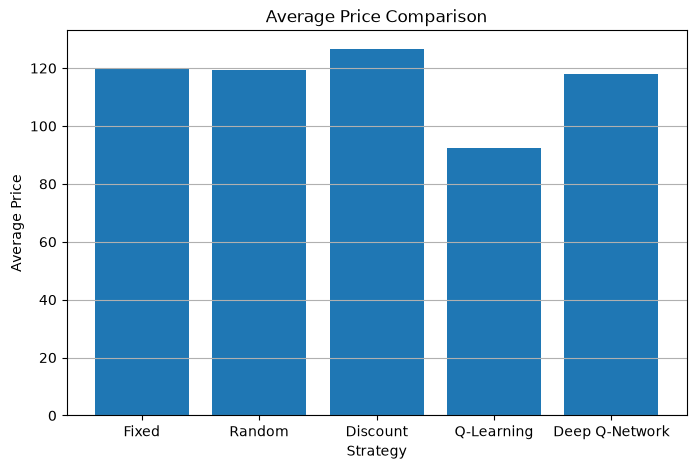

In [9]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Strategy"],comparison["Average Price"])

plt.title("Average Price Comparison")

plt.xlabel("Strategy")

plt.ylabel("Average Price")

plt.grid(axis="y")

plt.show()

In [10]:
best_revenue = comparison.loc[comparison["Average Revenue"].idxmax()]

best_occupancy = comparison.loc[comparison["Average Occupancy (%)"].idxmax()]

best_price = comparison.loc[comparison["Average Price"].idxmax()]

print("="*60)
print("Business Insights")
print("="*60)

print()

print(f"Highest Revenue Strategy : {best_revenue['Strategy']}")
print(f"Average Revenue : {best_revenue['Average Revenue']:.2f}")

print()

print(f"Highest Occupancy Strategy : {best_occupancy['Strategy']}")
print(f"Average Occupancy : {best_occupancy['Average Occupancy (%)']:.2f}%")

print()

print(f"Highest Average Price : {best_price['Strategy']}")
print(f"Average Price : {best_price['Average Price']:.2f}")

Business Insights

Highest Revenue Strategy : Fixed
Average Revenue : 3638.50

Highest Occupancy Strategy : Q-Learning
Average Occupancy : 93.26%

Highest Average Price : Discount
Average Price : 126.67


In [11]:
baseline = comparison[comparison["Strategy"]=="Q-Learning"]["Average Revenue"].values[0]

dqn_rev = comparison[comparison["Strategy"]=="Deep Q-Network"]["Average Revenue"].values[0]

improvement = ((dqn_rev-baseline)/baseline)*100

print(f"DQN Revenue Improvement over Q-Learning : {improvement:.2f}%")

DQN Revenue Improvement over Q-Learning : 16.38%
